<a href="https://colab.research.google.com/github/Ishini01/garment_defect_system/blob/main/BrokenStitchDetectionForShirtImages.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Broken Stitch Detection for Full Shirt Images

This notebook implements the deployment pipeline for detecting broken stitches from full shirt images.

The system uses a previously developed **weighted soft-voting ensemble** consisting of:

- MobileNetV2
- EfficientNetB0
- Vision Transformer (ViT)

Since the classification models were trained using stitch-focused images, a **Region of Interest (ROI) extraction pipeline** is also introduced to extract important stitching regions from a full shirt image before classification.

The overall workflow is:

1. Load the three trained models.
2. Configure the optimized ensemble weights.
3. Perform an initial prediction on the full shirt image.
4. Extract stitching-related Regions of Interest.
5. Classify each ROI using the weighted ensemble.
6. Produce a final shirt-level broken-stitch decision.

## 1. Mount Google Drive

Google Drive is mounted to access the saved `.keras` models and the shirt images used for inference.

In [1]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


## 2. Import Required Libraries

The required libraries are imported for:

- Loading the trained deep learning models
- Image preprocessing
- Numerical operations
- TensorFlow-based inference
- File and directory handling

MobileNetV2 uses its architecture-specific `preprocess_input()` function to prepare input images according to the preprocessing configuration used during training.

In [7]:
import os
import json
import numpy as np
import tensorflow as tf
import keras
import keras_hub

from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess

## 3. Define Saved Model Paths

The file paths of the three previously trained broken-stitch classifiers are defined below.

The ensemble uses:

- **MobileNetV2**
- **EfficientNetB0**
- **Vision Transformer (ViT)**

Each model is stored separately as a `.keras` file and is loaded independently during inference.

In [4]:
MOBILENET_PATH = "/content/drive/MyDrive/Dataset_GarmentDefectDetection/KaggleBrokenStitches/mobileNet_Model.keras"
EFFICIENTNET_PATH = "/content/drive/MyDrive/Dataset_GarmentDefectDetection/KaggleBrokenStitches/EfficientNet.keras"
VIT_PATH = "/content/drive/MyDrive/Dataset_GarmentDefectDetection/KaggleBrokenStitches/ViT_Model.keras"

## 4. Load the Trained Models

The three trained classification models are loaded into memory.

These models remain separate during deployment. Their predicted probabilities are later combined using the optimized weighted soft-voting ensemble.

In [6]:
import json
import numpy as np
import tensorflow as tf
import keras
import keras_hub

mobilenet_model = keras.models.load_model(MOBILENET_PATH)
efficientnet_model = keras.models.load_model(EFFICIENTNET_PATH)
vit_model = keras.models.load_model(VIT_PATH)

print("All models loaded successfully!")


All models loaded successfully!


## 5. Configure the Weighted Ensemble

The final ensemble uses validation-optimized weights obtained during the ensemble development stage.

The selected weights are:

- EfficientNetB0: **0.25**
- MobileNetV2: **0.40**
- Vision Transformer: **0.35**

The ensemble probability is calculated by combining the broken-stitch probabilities produced by all three classifiers.

A threshold of **0.50** is used for the final classification:

- Probability ≥ 0.50 → **Broken Stitches**
- Probability < 0.50 → **Normal Stitches**

In [8]:
ensemble_config = {
    "efficientnet_weight": 0.25,
    "mobilenet_weight": 0.40,
    "vit_weight": 0.35,
    "threshold": 0.50
}

print("Ensemble configuration loaded:")
print(ensemble_config)

Ensemble configuration loaded:
{'efficientnet_weight': 0.25, 'mobilenet_weight': 0.4, 'vit_weight': 0.35, 'threshold': 0.5}


## 6. Image Preprocessing for Ensemble Inference

Each input image is resized to **224 × 224 pixels** to match the expected input dimensions of the three classifiers.

Separate input arrays are prepared because the models use different preprocessing requirements.

- MobileNetV2 uses `mobilenet_v2.preprocess_input()`.
- EfficientNetB0 receives the resized image array according to its original training pipeline.
- ViT receives the resized image array according to its original model preprocessing pipeline.

The function returns one prepared input for each model.

In [9]:
IMG_SIZE = (224, 224)

def prepare_image(img_path):

    img = image.load_img(
        img_path,
        target_size=IMG_SIZE
    )

    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    mobile_img = mobilenet_preprocess(
        img_array.copy()
    )

    efficient_img = img_array.copy()
    vit_img = img_array.copy()

    return mobile_img, efficient_img, vit_img

## 7. Weighted Ensemble Prediction Function

This function performs the complete broken-stitch classification process for a single image.

The procedure is:

1. Preprocess the image for each model.
2. Obtain the broken-stitch probability from MobileNetV2.
3. Obtain the broken-stitch probability from EfficientNetB0.
4. Convert the ViT logits into probabilities using softmax.
5. Extract the ViT probability corresponding to the Broken Stitches class.
6. Combine the three probabilities using the optimized ensemble weights.
7. Apply the classification threshold of 0.50.

The function returns both the final ensemble prediction and the probability produced by each individual classifier.

In [10]:
def predict_broken_stitch(img_path):

    mobile_img, efficient_img, vit_img = prepare_image(img_path)

    # MobileNet
    mobile_prob = float(
        mobilenet_model.predict(
            mobile_img,
            verbose=0
        )[0][0]
    )

    # EfficientNet
    efficient_prob = float(
        efficientnet_model.predict(
            efficient_img,
            verbose=0
        )[0][0]
    )

    # ViT
    vit_logits = vit_model.predict(
        vit_img,
        verbose=0
    )

    vit_softmax = tf.nn.softmax(
        vit_logits,
        axis=1
    ).numpy()

    # column 1 = Broken Stitch
    vit_prob = float(
        vit_softmax[0][1]
    )

    # Weighted ensemble
    ensemble_prob = (
        ensemble_config["efficientnet_weight"] * efficient_prob
        +
        ensemble_config["mobilenet_weight"] * mobile_prob
        +
        ensemble_config["vit_weight"] * vit_prob
    )

    if ensemble_prob >= ensemble_config["threshold"]:
        label = "Broken Stitches"
    else:
        label = "Normal Stitches"

    return {
        "label": label,
        "ensemble_probability": ensemble_prob,
        "mobilenet_probability": mobile_prob,
        "efficientnet_probability": efficient_prob,
        "vit_probability": vit_prob
    }

## 8. Select a Full Shirt Image for Testing

A full short-sleeve shirt image is selected as the input for the deployment pipeline.

This differs from the stitch-focused images used during classifier development because the stitching occupies only a small portion of the complete shirt image.

In [11]:
IMG_PATH = "/content/drive/MyDrive/Dataset_GarmentDefectDetection/KaggleBrokenStitches/ShirtImage/Shirt1.jpg"

### 8.1 Initial Full-Image Ensemble Prediction

The complete shirt image is first passed directly to the weighted ensemble.

This experiment provides a baseline indication of how the classifier behaves when the entire shirt image is resized to the model input size.

However, because the stitching details may become very small after resizing the complete image, ROI-based classification is subsequently introduced to improve the relevance of the input regions.

In [12]:
result = predict_broken_stitch(
    IMG_PATH
)

print("FINAL RESULT")
print("----------------------")
print("Prediction:", result["label"])
print(
    f"Broken Stitch Probability: "
    f"{result['ensemble_probability']:.4f}"
)

print("\nIndividual Models")
print(
    f"MobileNet   : "
    f"{result['mobilenet_probability']:.4f}"
)

print(
    f"EfficientNet: "
    f"{result['efficientnet_probability']:.4f}"
)

print(
    f"ViT         : "
    f"{result['vit_probability']:.4f}"
)

FINAL RESULT
----------------------
Prediction: Broken Stitches
Broken Stitch Probability: 0.9815

Individual Models
MobileNet   : 0.9999
EfficientNet: 0.9909
ViT         : 0.9540


# Region of Interest (ROI) Extraction

The broken-stitch classifiers were trained primarily using images focused on stitching regions. Therefore, directly classifying a complete shirt image may reduce the visibility of small stitch defects.

To address this limitation, a Region of Interest extraction stage is introduced.

The ROI pipeline focuses on areas of a shirt where stitching commonly occurs, including:

- Collar
- Left sleeve
- Right sleeve
- Button placket
- Pocket
- Bottom hem

OpenCV is used for image processing, while Matplotlib is used to visualize the extracted regions.

In [13]:
import cv2
import matplotlib.pyplot as plt

## 9. Extract Stitching-Related Regions

A rule-based ROI extraction function is used to crop predefined regions from the full shirt image.

The crop boundaries are defined as proportions of the image height and width rather than fixed pixel coordinates. This allows the method to adapt to images of different resolutions.

The selected regions correspond to common stitching locations on a front-facing short-sleeve shirt:

- Collar
- Left sleeve
- Right sleeve
- Button placket
- Pocket
- Bottom hem

This approach assumes that the shirt is approximately centered and captured in a similar front-facing orientation.

In [14]:
def extract_shirt_rois(image_path):

    img = cv2.imread(image_path)

    if img is None:
        raise ValueError("Could not read image")

    img = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2RGB
    )

    h, w = img.shape[:2]

    rois = {}

    rois["collar"] = img[
        int(0.02*h):int(0.22*h),
        int(0.35*w):int(0.65*w)
    ]

    rois["left_sleeve"] = img[
        int(0.10*h):int(0.33*h),
        int(0.10*w):int(0.36*w)
    ]

    rois["right_sleeve"] = img[
        int(0.10*h):int(0.33*h),
        int(0.64*w):int(0.90*w)
    ]

    rois["button_placket"] = img[
        int(0.15*h):int(0.88*h),
        int(0.46*w):int(0.54*w)
    ]

    rois["pocket"] = img[
        int(0.27*h):int(0.55*h),
        int(0.54*w):int(0.72*w)
    ]

    rois["bottom_hem"] = img[
        int(0.82*h):int(0.97*h),
        int(0.25*w):int(0.78*w)
    ]

    return img, rois

### 9.1 Visualize the Extracted ROIs

The extracted regions are displayed to verify whether the predefined coordinates correctly capture the important stitching areas of the shirt.

Visual inspection is useful before classification because incorrect ROI boundaries may include irrelevant background regions or exclude important stitching details.

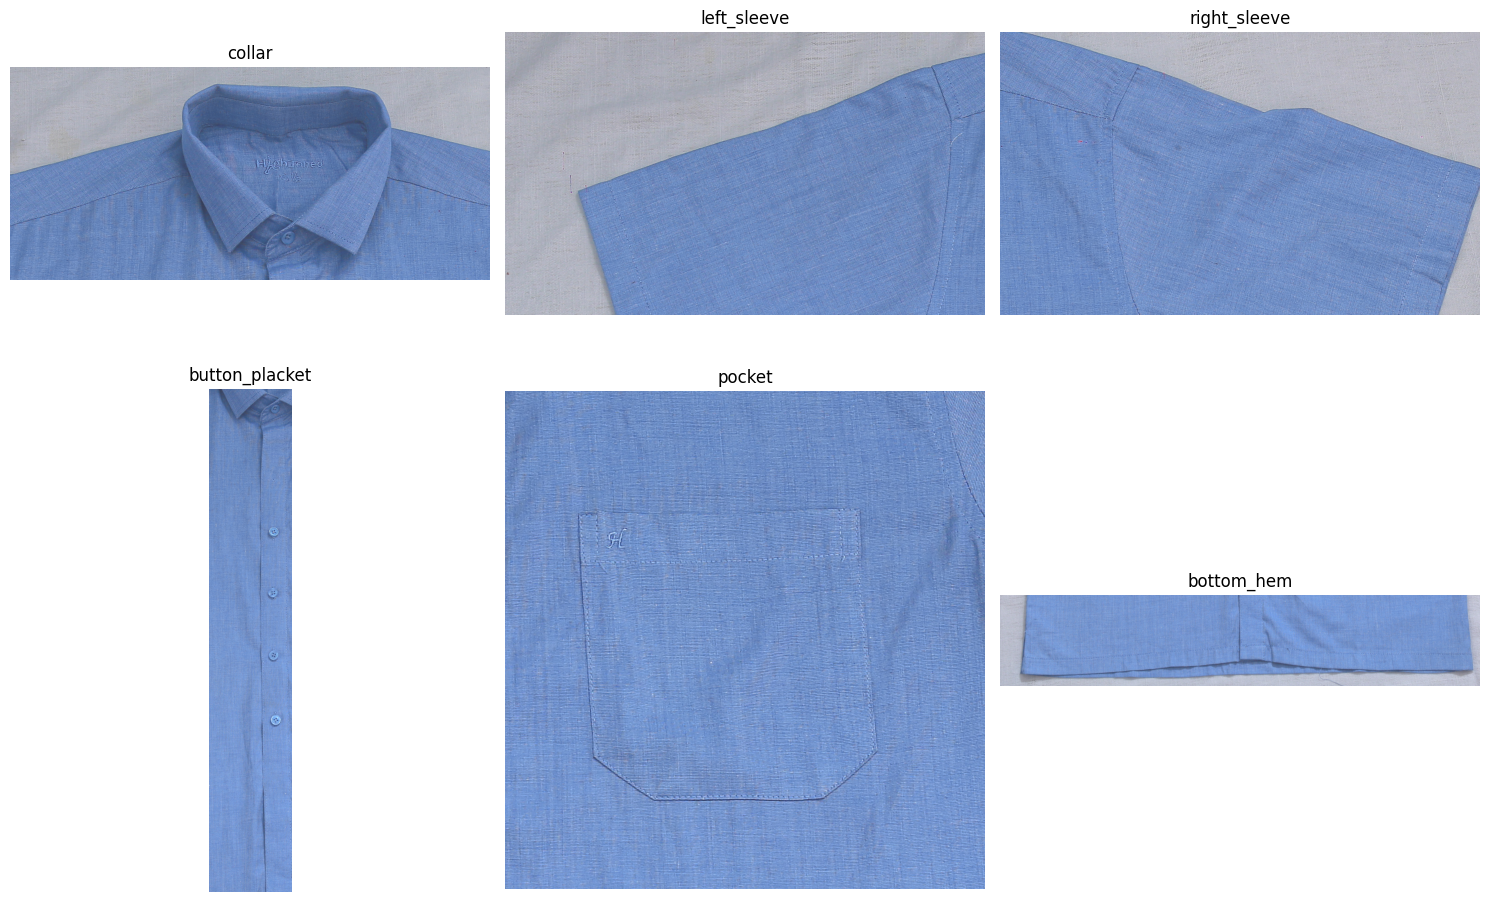

In [15]:
img, rois = extract_shirt_rois(
    IMG_PATH
)

plt.figure(figsize=(15, 10))

for i, (name, roi) in enumerate(
    rois.items(),
    1
):

    plt.subplot(2, 3, i)

    plt.imshow(roi)
    plt.title(name)
    plt.axis("off")

plt.tight_layout()
plt.show()

## 10. Save the Extracted ROI Images

Each extracted region is saved as a separate image file.

Saving the ROI crops provides a reusable intermediate representation that can be passed individually to the broken-stitch ensemble classifier.

The ROI images are stored in a dedicated directory in Google Drive.

In [17]:
ROI_DIR = "/content/drive/MyDrive/Dataset_GarmentDefectDetection/KaggleBrokenStitches/ShirtImage/roi_crops"

os.makedirs(
    ROI_DIR,
    exist_ok=True
)

for name, roi in rois.items():

    save_path = os.path.join(
        ROI_DIR,
        f"{name}.jpg"
    )

    roi_bgr = cv2.cvtColor(
        roi,
        cv2.COLOR_RGB2BGR
    )

    cv2.imwrite(
        save_path,
        roi_bgr
    )

print("ROI crops saved.")

ROI crops saved.


## 11. Classify Each ROI Using the Weighted Ensemble

Each saved stitching region is independently passed through the weighted ensemble classifier.

For every ROI, the system calculates the combined probability of the **Broken Stitches** class using:

- EfficientNetB0
- MobileNetV2
- Vision Transformer

The result for each region is stored for subsequent region-level and shirt-level analysis.

In [18]:
roi_results = {}

for roi_name in rois.keys():

    roi_path = os.path.join(
        ROI_DIR,
        f"{roi_name}.jpg"
    )

    result = predict_broken_stitch(
        roi_path
    )

    roi_results[roi_name] = result

### 11.1 Display Region-Level Predictions

The classification result and ensemble broken-stitch probability are displayed for each extracted ROI.

This provides more detailed information than a single shirt-level prediction because it indicates which stitching region may contain a defect.

In [19]:
for roi_name, result in roi_results.items():

    print(
        f"{roi_name:20s} | "
        f"{result['label']:16s} | "
        f"P(Broken) = "
        f"{result['ensemble_probability']:.4f}"
    )

collar               | Broken Stitches  | P(Broken) = 0.7514
left_sleeve          | Broken Stitches  | P(Broken) = 0.7738
right_sleeve         | Broken Stitches  | P(Broken) = 0.8153
button_placket       | Broken Stitches  | P(Broken) = 0.9008
pocket               | Broken Stitches  | P(Broken) = 0.7521
bottom_hem           | Broken Stitches  | P(Broken) = 0.9066


## 12. Generate the Final Shirt-Level Decision

The predictions from all ROIs are combined to obtain the final result for the shirt.

If at least one ROI has a broken-stitch probability greater than or equal to the classification threshold, the shirt is classified as containing a broken stitch.

Otherwise, the shirt is classified as having no detected broken stitches.

The detected regions are also reported to provide information about the possible location of the defect.

In [20]:
broken_regions = []

for roi_name, result in roi_results.items():

    if result["ensemble_probability"] >= 0.5:
        broken_regions.append(
            roi_name
        )

if broken_regions:

    print("Broken Stitch Detected")

    print(
        "Affected regions:",
        broken_regions
    )

else:

    print(
        "No Broken Stitch Detected"
    )

Broken Stitch Detected
Affected regions: ['collar', 'left_sleeve', 'right_sleeve', 'button_placket', 'pocket', 'bottom_hem']


## 13. Pipeline Summary

The final broken-stitch detection pipeline processes a complete shirt image through two main stages.

### Stage 1 — Region Extraction

The full shirt image is divided into predefined stitching-related Regions of Interest:

- Collar
- Left sleeve
- Right sleeve
- Button placket
- Pocket
- Bottom hem

### Stage 2 — Ensemble Classification

Each extracted ROI is classified using a heterogeneous weighted soft-voting ensemble consisting of:

- MobileNetV2
- EfficientNetB0
- Vision Transformer

The final ensemble weights are:

| Model | Weight |
|---|---:|
| MobileNetV2 | 0.40 |
| EfficientNetB0 | 0.25 |
| Vision Transformer | 0.35 |

Each ROI is classified independently as either **Normal Stitches** or **Broken Stitches**.

If one or more regions are classified as defective, the overall shirt is reported as containing a possible broken-stitch defect.

### Current Limitation

The current ROI extraction method uses predefined geometric locations and therefore assumes that the shirt is approximately centered, front-facing, and positioned consistently.

Future improvements may use automatic garment segmentation or seam localization to dynamically identify relevant stitching regions under varying image positions, orientations, and scales.